In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

In [2]:
DATA_PATH = "data/UNSW_NB15_training-set.csv"

RANDOM_STATE = 42
VAL_SIZE = 0.2
PERCENTILE = 98

In [3]:
df = pd.read_csv(DATA_PATH, encoding="latin1")
print("Original shape:", df.shape)

Original shape: (175341, 45)


In [4]:
if "label" not in df.columns:
    raise ValueError("Column 'label' not found in dataset.")

df["target"] = df["label"].astype(int)

print(df["target"].value_counts())

target
1    119341
0     56000
Name: count, dtype: int64


In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

feature_cols = [
    c for c in numeric_cols
    if c.lower() != "target"
    and "label" not in c.lower()
    and "attack" not in c.lower()
]

print("All numeric columns:", len(numeric_cols))
print("Feature columns used for modeling:", len(feature_cols))
print("Removed columns:", [c for c in numeric_cols if c not in feature_cols])

All numeric columns: 42
Feature columns used for modeling: 40
Removed columns: ['label', 'target']


In [6]:
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

before_drop = df.shape[0]
df = df.dropna(subset=feature_cols).reset_index(drop=True)
after_drop = df.shape[0]

print(f"Rows removed during cleaning: {before_drop - after_drop}")
print("Cleaned shape:", df.shape)

Rows removed during cleaning: 0
Cleaned shape: (175341, 46)


In [7]:
X = df[feature_cols].copy()
y = df["target"].values.astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:", np.bincount(y))

X shape: (175341, 40)
y shape: (175341,)
Class distribution: [ 56000 119341]


In [8]:
normal_mask = (y == 0)

X_normal = X.loc[normal_mask].copy()

X_train, X_val = train_test_split(
    X_normal,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

X_test = X.copy()
y_test = y.copy()

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (44800, 40)
X_val shape: (11200, 40)
X_test shape: (175341, 40)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

In [10]:
from sklearn.svm import OneClassSVM

model = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.05
)

model.fit(X_train_scaled)
print("One-Class SVM trained successfully.")

One-Class SVM trained successfully.


In [11]:
scores_val = -model.decision_function(X_val_scaled)
scores_test = -model.decision_function(X_test_scaled)

print("Validation score range:", scores_val.min(), scores_val.max())
print("Test score range:", scores_test.min(), scores_test.max())

Validation score range: -45.30049416187668 63.24371812960266
Test score range: -45.68510368434249 63.244483031857065


In [12]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, roc_thresholds = roc_curve(y_test, scores_test)
roc_auc = auc(fpr, tpr)

PERCENTILES = [99, 98, 95, 90, 85, 80, 70, 60, 50]

results = []

for p in PERCENTILES:
    threshold = np.percentile(scores_val, p)
    y_pred_p = (scores_test >= threshold).astype(int)

    acc_p = accuracy_score(y_test, y_pred_p)
    prec_p = precision_score(y_test, y_pred_p, zero_division=0)
    rec_p = recall_score(y_test, y_pred_p, zero_division=0)
    f1_p = f1_score(y_test, y_pred_p, zero_division=0)

    results.append({
        "Percentil": p,
        "Threshold": threshold,
        "Precision": prec_p,
        "Recall": rec_p,
        "F1-score": f1_p,
        "Accuracy": acc_p,
        "AUC": roc_auc,
        "Predicted anomalies": int(y_pred_p.sum())
    })

results_df = pd.DataFrame(results)
results_df

,Percentil,Threshold,Precision,Recall,F1-score,Accuracy,AUC,Predicted anomalies
0,99,27.078405,0.984472,0.313446,0.475499,0.529351,0.811218,37997
1,98,12.363050,0.976746,0.377297,0.544330,0.570061,0.811218,46099
2,95,0.060128,0.955092,0.483488,0.641988,0.632978,0.811218,60413
3,90,-1.994930,0.917091,0.505518,0.651769,0.632339,0.811218,65783
4,85,-5.319010,0.886314,0.544566,0.674629,0.642480,0.811218,73325
5,80,-10.012786,0.867291,0.612782,0.718154,0.672632,0.811218,84320
6,70,-16.625041,0.842675,0.751552,0.794510,0.735401,0.811218,106436
7,60,-19.634877,0.815217,0.823271,0.819224,0.752705,0.811218,120520
8,50,-21.795289,0.789652,0.870237,0.827988,0.753902,0.811218,131520


In [13]:
threshold = np.percentile(scores_val, PERCENTILE)
y_pred = (scores_test >= threshold).astype(int)

print(f"Threshold (percentile={PERCENTILE}):", threshold)

Threshold (percentile=98): 12.363049854228972


In [14]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("=== One-Class SVM ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

=== One-Class SVM ===
Accuracy : 0.5701
Precision: 0.9767
Recall   : 0.3773
F1-score : 0.5443


              precision    recall  f1-score   support

           0     0.4250    0.9809    0.5930     56000
           1     0.9767    0.3773    0.5443    119341

    accuracy                         0.5701    175341
   macro avg     0.7009    0.6791    0.5687    175341
weighted avg     0.8005    0.5701    0.5599    175341



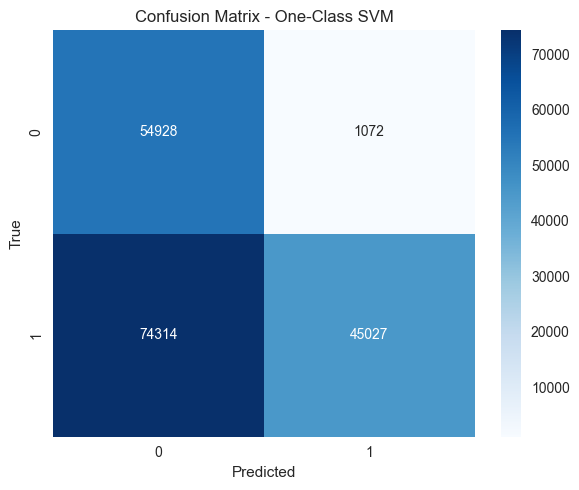

In [15]:
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - One-Class SVM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

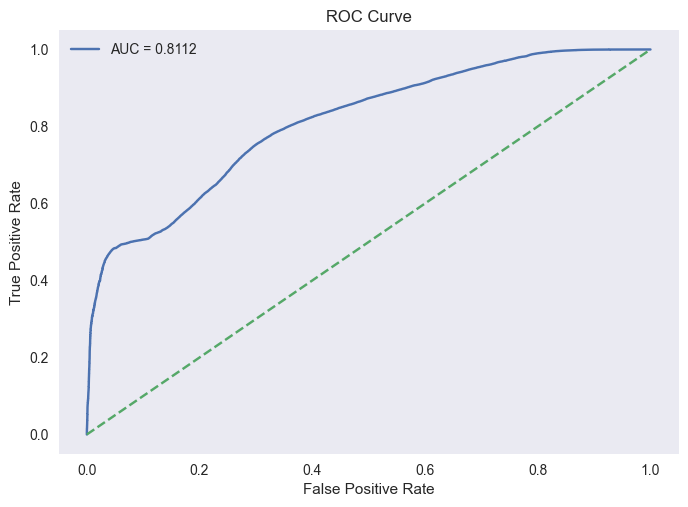

AUC: 0.8112182539350026


In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, scores_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

print("AUC:", roc_auc)